# SAT Mapping

Here, we show that how the optimization problem is mapped to the one-dimensional lattice that is implicitly defined by the MPS evaluator has a large impact on the simulation accuracy.
This is studied for random three-regular graphs.
The topology of an MPS tensor network is linear, and qubits which are strongly entangled should be placed close one to each other when mapping them to the MPS.
To this end, we can therefore use the SAT mapping for hardware developped by Matsuo *et al.* in Ref. [1].
We evaluate depth-one QAOA at a near optimal point and compare the MPS evaluator to the result of the exact efficient depth-one evaluator.

#### References

[1] A. Matsuo, S. Yamashita, D. J. Egger, *"A SAT approach to the initial mapping problem in SWAP gate insertion for commuting gates"*, IEICE Transactions on Fundamentals of Electronics, Communications and Computer Sciences **106**, 11 (2023).

In [2]:
import time
import matplotlib.pyplot as plt
import numpy as np

from qiskit.transpiler.passes.routing.commuting_2q_gate_routing import SwapStrategy

from qopt_best_practices.sat_mapping import SATMapper

from qaoa_training_pipeline.evaluation import MPSEvaluator, EfficientDepthOneEvaluator, MPSAerEvaluator
from qaoa_training_pipeline.training import DepthOneScanTrainer
from qaoa_training_pipeline.utils.graph_utils import load_graph, graph_to_operator

In [9]:
indices = list(range(5))

graph_sets = {
    "N40R3R": [
        load_graph(f"../instances/random_regular/00{idx}_40nodes_random3regular.json")
        for idx in indices
    ],
    "N100L2S2": [
        load_graph(f"../instances/line_to_full/00{idx}_100nodes_2swap_layers.json")
        for idx in indices
    ],
}

cost_ops = {
    name: [graph_to_operator(graph, pre_factor=-0.5) for graph in graphs]
    for name, graphs in graph_sets.items()
}

In [10]:
ed_evaluator = EfficientDepthOneEvaluator()

trainers = [DepthOneScanTrainer(ed_evaluator) for _ in graphs]

In [11]:
sat_graphs = {}
n_layers = {}
mapping_times = {}

for short_name, graphs in graph_sets.items():
    swap_strategy = SwapStrategy.from_line(range(graphs[0].order()))

    sat_graphs[short_name] = []
    n_layers[short_name] = []
    mapping_times[short_name] = []

    for idx, graph in enumerate(graphs):
        start = time.time()

        sat_graph, _, layers = SATMapper(timeout=10).remap_graph_with_sat(
            graph=graph,
            swap_strategy=swap_strategy,
        )

        elapsed = time.time() - start

        sat_graphs[short_name].append(sat_graph)
        n_layers[short_name].append(layers)
        mapping_times[short_name].append(elapsed)

        print(f"{short_name}: mapped graph {idx} in {elapsed:.0f} sec")

N40R3R: mapped graph 0 in 30 sec
N40R3R: mapped graph 1 in 26 sec
N40R3R: mapped graph 2 in 23 sec
N40R3R: mapped graph 3 in 27 sec
N40R3R: mapped graph 4 in 24 sec
N100L2S2: mapped graph 0 in 28 sec
N100L2S2: mapped graph 1 in 29 sec
N100L2S2: mapped graph 2 in 32 sec
N100L2S2: mapped graph 3 in 26 sec
N100L2S2: mapped graph 4 in 24 sec


In [12]:
all_params = {}
all_trainers = {}
all_results = {}

for short_name, ops in cost_ops.items():
    all_params[short_name] = []
    all_trainers[short_name] = []
    all_results[short_name] = []

    for idx, cost_op in enumerate(ops):
        trainer = DepthOneScanTrainer(EfficientDepthOneEvaluator())

        result = trainer.train(
            cost_op,
            parameter_ranges=((0, np.pi / 2), (0, np.pi / 2)),
        )

        all_results[short_name].append(result)
        all_params[short_name].append(result["optimized_params"])
        all_trainers[short_name].append(trainer)

        print(f"{short_name}: trained graph {idx}")

N40R3R: trained graph 0
N40R3R: trained graph 1
N40R3R: trained graph 2
N40R3R: trained graph 3
N40R3R: trained graph 4
N100L2S2: trained graph 0
N100L2S2: trained graph 1
N100L2S2: trained graph 2
N100L2S2: trained graph 3
N100L2S2: trained graph 4


(<Figure size 640x480 with 2 Axes>,
 <Axes: xlabel='$\\gamma$', ylabel='$\\beta$'>)

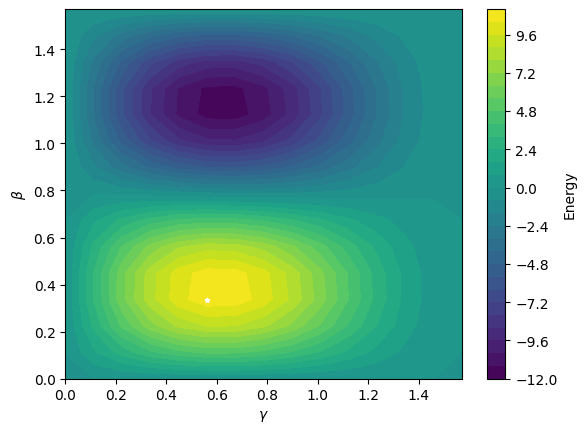

In [15]:
all_trainers['N40R3R'][0].plot()

In [17]:
def get_mps_evaluator(bond_dim, truncation_threshold=1.0e-10) -> MPSEvaluator:
    return MPSEvaluator(
        bond_dim_circuit=bond_dim, 
        threshold_circuit=truncation_threshold, 
        use_vidal_form=True, 
        use_swap_strategy=True,
        store_schmidt_values=True,
        store_intermediate_schmidt_values=True
    )

In [18]:
def get_mps_aer_evaluator(bond_dim, truncation_threshold=1.0e-10) -> MPSAerEvaluator:
    mps_init_args= {
                    "matrix_product_state_max_bond_dimension": bond_dim,
                    "matrix_product_state_truncation_threshold": truncation_threshold,
                    "method": "matrix_product_state"
                }
    return MPSAerEvaluator(
        mps_init_args=mps_init_args
    )

In [19]:
sat_cost_ops = {}

all_sat_ed_energies = {}
all_ed_energies = {}

all_mps_energies = {}
all_sat_mps_energies = {}

all_times = {}
all_sat_times = {}

all_bounds = {}
all_sat_bounds = {}
all_estimates = {}
all_sat_estimates = {}

bond_dims = [2, 4, 8, 16, 32, 64]

for short_name in graph_sets.keys():
    print(f"\nGraph family: {short_name}")

    sat_cost_ops[short_name] = []

    all_ed_energies[short_name] = []
    all_sat_ed_energies[short_name] = []

    all_mps_energies[short_name] = {"Quimb": [], "Aer": []}
    all_sat_mps_energies[short_name] = {"Quimb": [], "Aer": []}

    all_times[short_name] = {"Quimb": [], "Aer": []}
    all_sat_times[short_name] = {"Quimb": [], "Aer": []}

    all_bounds[short_name] = []
    all_sat_bounds[short_name] = []
    all_estimates[short_name] = []
    all_sat_estimates[short_name] = []

    for bond_dim in bond_dims:
        print(f"  Bond dimension {bond_dim}")

        sat_ed_energies = []
        ed_energies = []

        mps_energies = []
        sat_mps_energies = []

        mps_aer_energies = []
        sat_mps_aer_energies = []

        times = []
        sat_times = []

        aer_times = []
        aer_sat_times = []

        for idx, sat_graph in enumerate(sat_graphs[short_name]):
            print(f"    On index {idx}")

            params = all_params[short_name][idx]

            sat_cost_op = graph_to_operator(sat_graph, pre_factor=-0.5)
            sat_cost_ops[short_name].append(sat_cost_op)

            ed_energies.append(
                float(ed_evaluator.evaluate(cost_ops[short_name][idx], params))
            )

            sat_ed_energies.append(
                float(ed_evaluator.evaluate(sat_cost_op, params))
            )

            mps_evaluator_1 = get_mps_evaluator(bond_dim)
            mps_evaluator_2 = get_mps_evaluator(bond_dim)
            mps_aer_evaluator_1 = get_mps_aer_evaluator(bond_dim)
            mps_aer_evaluator_2 = get_mps_aer_evaluator(bond_dim)

            start = time.time()
            mps_energies.append(
                float(mps_evaluator_1.evaluate(cost_ops[short_name][idx], params))
            )
            times.append(time.time() - start)

            start = time.time()
            sat_mps_energies.append(
                float(mps_evaluator_2.evaluate(sat_cost_op, params))
            )
            sat_times.append(time.time() - start)

            start = time.time()
            mps_aer_energies.append(
                float(mps_aer_evaluator_1.evaluate(cost_ops[short_name][idx], params))
            )
            aer_times.append(time.time() - start)

            start = time.time()
            sat_mps_aer_energies.append(
                float(mps_aer_evaluator_2.evaluate(sat_cost_op, params))
            )
            aer_sat_times.append(time.time() - start)

        all_ed_energies[short_name].append(ed_energies)
        all_sat_ed_energies[short_name].append(sat_ed_energies)

        all_mps_energies[short_name]["Quimb"].append(mps_energies)
        all_sat_mps_energies[short_name]["Quimb"].append(sat_mps_energies)

        all_times[short_name]["Quimb"].append(times)
        all_sat_times[short_name]["Quimb"].append(sat_times)

        all_mps_energies[short_name]["Aer"].append(mps_aer_energies)
        all_sat_mps_energies[short_name]["Aer"].append(sat_mps_aer_energies)

        all_times[short_name]["Aer"].append(aer_times)
        all_sat_times[short_name]["Aer"].append(aer_sat_times)


Graph family: N40R3R
  Bond dimension 2
    On index 0
    On index 1
    On index 2
    On index 3
    On index 4
  Bond dimension 4
    On index 0
    On index 1
    On index 2
    On index 3
    On index 4
  Bond dimension 8
    On index 0
    On index 1
    On index 2
    On index 3
    On index 4
  Bond dimension 16
    On index 0
    On index 1
    On index 2
    On index 3
    On index 4
  Bond dimension 32
    On index 0
    On index 1
    On index 2
    On index 3
    On index 4
  Bond dimension 64
    On index 0
    On index 1
    On index 2
    On index 3
    On index 4

Graph family: N100L2S2
  Bond dimension 2
    On index 0
    On index 1
    On index 2
    On index 3
    On index 4
  Bond dimension 4
    On index 0
    On index 1
    On index 2
    On index 3
    On index 4
  Bond dimension 8
    On index 0
    On index 1
    On index 2
    On index 3
    On index 4
  Bond dimension 16
    On index 0
    On index 1
    On index 2
    On index 3
    On index 4
  Bond dim

In [20]:
for short_name in graph_sets.keys():
    assert np.allclose(
        all_ed_energies[short_name],
        all_sat_ed_energies[short_name],
    ), f"ED energies do not match for {short_name}"

In [21]:
def to_numpy_nested(obj):
    if isinstance(obj, dict):
        return {
            key: to_numpy_nested(value)
            for key, value in obj.items()
        }
    return np.array(obj)

In [22]:
all_ed_energies = to_numpy_nested(all_ed_energies)
all_sat_ed_energies = to_numpy_nested(all_sat_ed_energies)
all_mps_energies = to_numpy_nested(all_mps_energies)
all_sat_mps_energies = to_numpy_nested(all_sat_mps_energies)
all_times = to_numpy_nested(all_times)
all_sat_times = to_numpy_nested(all_sat_times)

In [23]:
def relative_errors(mps_data, ed_data, backend):
    return {
        short_name: (mps_data[short_name][backend] - ed_data[short_name])
        / ed_data[short_name]
        for short_name in ed_data.keys()
    }

In [24]:
rel_errors = relative_errors(all_mps_energies, all_ed_energies, "Quimb")
rel_sat_errors = relative_errors(all_sat_mps_energies, all_ed_energies, "Quimb")

rel_aer_errors = relative_errors(all_mps_energies, all_ed_energies, "Aer")
rel_aer_sat_errors = relative_errors(all_sat_mps_energies, all_ed_energies, "Aer")

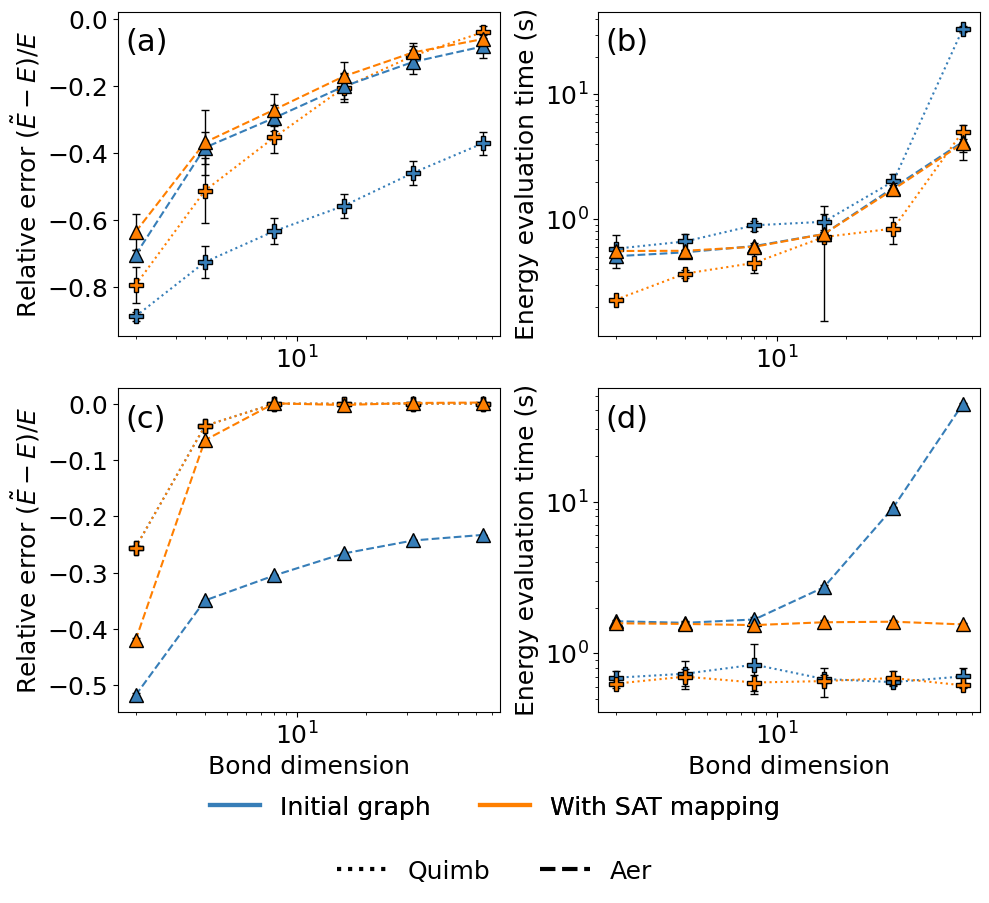

In [28]:
from matplotlib.lines import Line2D

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

opts = {
    "marker": "P",
    "mec": "k",
    "ecolor": "k",
    "capsize": 3,
    "elinewidth": 1,
    "linestyle": ":",
    "ms": 10,
}

opts2 = {
    "marker": "^",
    "mec": "k",
    "ecolor": "k",
    "capsize": 3,
    "elinewidth": 1,
    "linestyle": "--",
    "ms": 10,
}

blue = "#377eb8"
orange = "#ff7f00"

graph_order = ["N40R3R", "N100L2S2"]

for row, short_name in enumerate(graph_order):
    ax_err = axs[row, 0]
    ax_time = axs[row, 1]

    errors = [
        (rel_errors[short_name],         rel_errors[short_name],         "Initial graph (Quimb)",    opts,  blue),
        (rel_sat_errors[short_name],     rel_sat_errors[short_name],     "With SAT mapping (Quimb)", opts,  orange),
        (rel_aer_errors[short_name],     rel_errors[short_name],         "Initial graph (Aer)",      opts2, blue),
        (rel_aer_sat_errors[short_name], rel_sat_errors[short_name],     "With SAT mapping (Aer)",   opts2, orange),
    ]

    for data, err_data, label, style, color in errors:
        ax_err.errorbar(
            bond_dims,
            np.average(data, axis=1),
            yerr=np.std(err_data, axis=1),
            label=label,
            color=color,
            **style,
        )

    ax_err.set_ylabel(r"Relative error $(\tilde{E}-E)/E$", fontsize=18)
    ax_err.set_xscale("log")

    times = [
        (all_times[short_name]["Quimb"],     "Initial graph (Quimb)",    opts,  blue),
        (all_sat_times[short_name]["Quimb"], "With SAT mapping (Quimb)", opts,  orange),
        (all_times[short_name]["Aer"],       "Initial graph (Aer)",      opts2, blue),
        (all_sat_times[short_name]["Aer"],   "With SAT mapping (Aer)",   opts2, orange),
    ]

    for data, label, style, color in times:
        ax_time.errorbar(
            bond_dims,
            np.average(data, axis=1),
            yerr=np.std(data, axis=1),
            label=label,
            color=color,
            **style,
        )

    ax_time.set_ylabel("Energy evaluation time (s)", fontsize=18)
    ax_time.set_xscale("log")
    ax_time.set_yscale("log")

axs[1, 0].set_xlabel("Bond dimension", fontsize=18)
axs[1, 1].set_xlabel("Bond dimension", fontsize=18)

for ax in axs.flat:
    ax.tick_params(axis="both", labelsize=18)

subplot_labels = ["(a)", "(b)", "(c)", "(d)"]

for ax, label in zip(axs.flat, subplot_labels):
    ax.text(
        0.02,
        0.95,
        label,
        transform=ax.transAxes,
        fontsize=22,
        va="top",
        ha="left",
    )

color_handles = [
    Line2D([0], [0], color=blue, lw=3, label="Initial graph"),
    Line2D([0], [0], color=orange, lw=3, label="With SAT mapping"),
]

style_handles = [
    Line2D(
        [0], [0],
        color="black",
        lw=3,
        linestyle=opts["linestyle"],
        label="Quimb",
    ),
    Line2D(
        [0], [0],
        color="black",
        lw=3,
        linestyle=opts2["linestyle"],
        label="Aer",
    ),
]

legend1 = fig.legend(
    handles=color_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.06),
    ncol=2,
    frameon=False,
    fontsize=18,
)

legend2 = fig.legend(
    handles=style_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.14),
    ncol=2,
    frameon=False,
    fontsize=18,
)

fig.add_artist(legend1)

fig.tight_layout()
fig.savefig("sat_mapping_impact.pdf", bbox_inches="tight")